<a href="https://colab.research.google.com/github/Fillelur/simple-AI-stuff/blob/main/python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    size  rooms   age     price
0   50.0    2.0  30.0  150000.0
1   60.0    3.0  20.0  180000.0
2   80.0    3.0  15.0  240000.0
3    NaN    4.0  10.0  280000.0
4  120.0    NaN   5.0  350000.0
5  150.0    5.0   NaN  420000.0
6  200.0    6.0   2.0       NaN
7   90.0    3.0  12.0  260000.0
8    NaN    4.0   7.0  310000.0
9  130.0    5.0   NaN       NaN

Efter fix:
    size  rooms   age     price
0   50.0    2.0  30.0  150000.0
1   60.0    3.0  20.0  180000.0
2   80.0    3.0  15.0  240000.0
3  105.0    4.0  10.0  280000.0
4  120.0    4.0   5.0  350000.0
5  150.0    5.0  11.0  420000.0
6  200.0    6.0   2.0  270000.0
7   90.0    3.0  12.0  260000.0
8  105.0    4.0   7.0  310000.0
9  130.0    5.0  11.0  270000.0


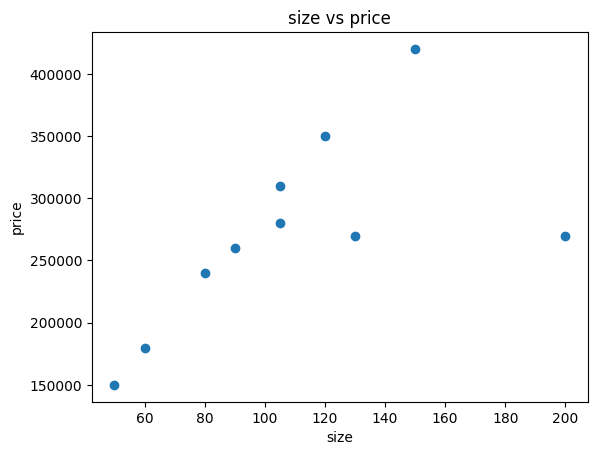


linjär regression:
MSE: 2117176914.3976393
R2: 0.49889303801239304

decision tree depth 2:
MSE: 4450000000.0
R2: -0.053254437869822535

decision tree depth 3:
MSE: 2900000000.0
R2: 0.31360946745562135

decision tree depth 5:
MSE: 2250000000.0
R2: 0.4674556213017751

bästa depth: 5

predicted price: [260000.]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# testdata (med olika typer av saknade värden)
data = {
    "size": [50, 60, 80, None, 120, 150, 200, 90, float('nan'), 130],
    "rooms": [2, 3, 3, 4, np.nan, 5, 6, 3, 4, 5],
    "age": [30, 20, 15, 10, 5, None, 2, 12, 7, np.nan],
    "price": [150000, 180000, 240000, 280000, 350000, 420000, None, 260000, 310000, float('nan')]
}

df = pd.DataFrame(data)

print(df)

# fyller i saknade värden (median istället för mean)
df = df.fillna(df.median())

print("\nEfter fix:")
print(df)

# enkel graf
plt.scatter(df["size"], df["price"])
plt.xlabel("size")
plt.ylabel("price")
plt.title("size vs price")
plt.show()

# dela upp data
X = df[["size", "rooms", "age"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# linjär regression först
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

print("\nlinjär regression:")
print("MSE:", mean_squared_error(y_test, lin_pred))
print("R2:", r2_score(y_test, lin_pred))


# decision tree (testar lite olika depth)
best_r2 = -999
best_depth = 0

for d in [2, 3, 5]:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)

    pred = tree.predict(X_test)
    r2 = r2_score(y_test, pred)

    print(f"\ndecision tree depth {d}:")
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2:", r2)

    if r2 > best_r2:
        best_r2 = r2
        best_depth = d

print("\nbästa depth:", best_depth)

# använder bästa modellen på ny data
final_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
final_model.fit(X, y)

new_house = pd.DataFrame([[90, 3, 10]], columns=["size", "rooms", "age"])
print("\npredicted price:", final_model.predict(new_house))